In [1]:
# ===========================================================================
# CONFIG LOADER  --  edit config.py, NOT this cell.
# Gives you `cfg` (every country knob) and `P` (the standard paths).
# ===========================================================================
import os, sys, importlib.util

# config.py lives in activity/, beside this notebook.
# From activity/ that is simply the current folder; from solutions/ it is next door.
CODE_DIR = os.getcwd()
if not os.path.exists(os.path.join(CODE_DIR, "config.py")):
    CODE_DIR = os.path.abspath(os.path.join(CODE_DIR, "..", "activity"))

_spec = importlib.util.spec_from_file_location("config", os.path.join(CODE_DIR, "config.py"))
cfg = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(cfg)
P = cfg.derive_paths(CODE_DIR)     # creates raw/, data/, output/, logs/ if missing

print(f"[CONFIG] {cfg.COUNTRY} ({cfg.CODE}) | reading output/{cfg.DATE_STR}/")


[CONFIG] Jamaica (JM) | reading output/20260806/


# Results

Estimation results are stored in 3 files: the point estimates, the performance (RMSE), and out-of-sample estimates

In [2]:
import numpy as np
import pandas as pd
import os

# DATE_STR comes from config.py, the same value act8_nwcst stamped its output with,
# so these two notebooks cannot drift. To review an older run, pin DATE_STR there.
date_str    = cfg.DATE_STR
PATH_DATA   = P["data"]
PATH_OUTPUT = os.path.join(P["output"], date_str)

forecast_file     = f"{date_str} 3_nwcst Tab fcst.xlsx"   # model forecasts / nowcasts
performance_file  = f"{date_str} 3_nwcst Tab perf.xlsx"   # model performance metrics
outofsample_file  = f"{date_str} 3_nwcst Tab oos.xlsx"    # full OOS prediction panel


results_table = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", index_col='date')
results_table.index = pd.to_datetime(results_table.index, format="%Y-%m-%d")
performance_table = pd.read_excel(f"{PATH_OUTPUT}/{performance_file}", index_col='Vintage')
#outofsample_table = pd.read_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_col='date')


**Inspect the performance table.** This shows each model's prediction error (RMSE) broken down by forecasting horizon ("Vintage"): negative numbers mean the data was already published when the model ran; positive means it was predicting quarters that had not been released yet.

In [3]:
performance_table

,RMSE,estimator,spec
Vintage,,,
-2,28.649759,OLS,lars19
-1,14.519110,OLS,lars19
0,13.600697,OLS,lars19
1,12.594481,OLS,lars19
2,4.416336,OLS,lars19
...,...,...,...
-2,2.703626,LSTM,lars44
-1,2.854073,LSTM,lars44
0,2.883411,LSTM,lars44


**Check which model specifications are present** in the performance data.

In [4]:
performance_table['spec'].unique()

array(['lars19', 'lars44'], dtype=object)

**Inspect the results table.** This contains the actual nowcast values produced by each model, for each quarter and each forecasting horizon.

In [5]:
results_table

,actuals,two_back,one_back,zero_back,one_ahead,two_ahead,estimator,spec
date,,,,,,,,
2023-06-01,-0.066758,0.142740,0.374852,1.948525,1.991394,0.754968,OLS,lars19
2023-09-01,1.988200,0.362125,-0.541925,-0.507473,0.789139,0.188135,OLS,lars19
2023-12-01,-0.778219,4.725324,-5.793553,-5.887483,-6.618359,1.410595,OLS,lars19
2024-03-01,-0.054704,-73.690762,0.033802,0.495400,0.059551,-7.136781,OLS,lars19
2024-06-01,-0.997453,1.938280,-11.574053,2.092672,2.038946,1.935090,OLS,lars19
...,...,...,...,...,...,...,...,...
2025-03-01,1.086629,0.203725,0.161855,0.180771,0.161807,0.571354,LSTM,lars44
2025-06-01,0.255034,1.339006,0.836444,0.874057,1.091872,0.920585,LSTM,lars44
2025-09-01,0.350465,1.070109,0.862003,0.949552,0.898504,1.004162,LSTM,lars44


**Check which model specifications are present** in the results data.

In [6]:
results_table['spec'].unique()

array(['lars19', 'lars44'], dtype=object)

# Presenting Results

**Set up plotting libraries and color palette.** We import the tools needed to draw charts and define the IDB color scheme used throughout.

In [7]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

# Define the color scheme
idb_blue = "#005BAC"
idb_light_blue = "#7FB3E6"

## Average RMSE by publication lag

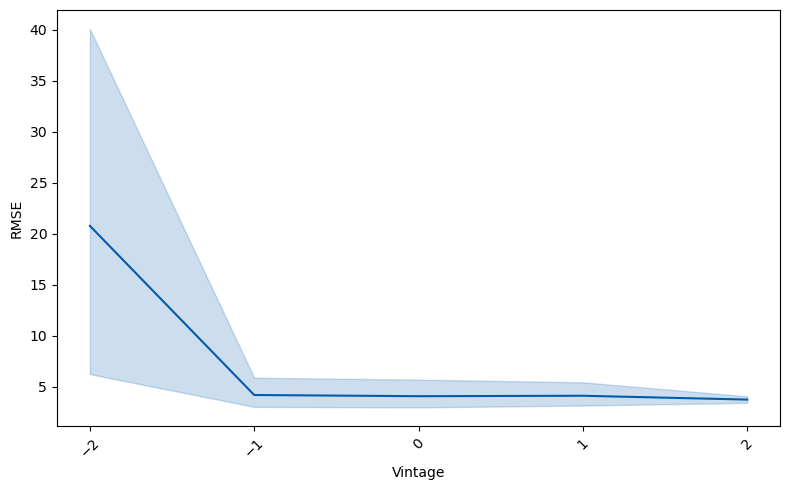

In [8]:
all_means = performance_table.groupby(performance_table.index)['RMSE'].mean()


fig, axes = plt.subplots(1, 1, figsize=(8, 5))  # adjust figsize as you want
# If axes is a single AxesSubplot (not an array), make it a list for consistency
axes = [axes]

# Plot
sns.lineplot(data=performance_table, x='Vintage', y='RMSE', ax=axes[0], color=idb_blue)

axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
axes[0].set_title("")
axes[0].tick_params(axis='x', rotation=45)
plt.tight_layout()

# Save figure:
plt.savefig(f'{PATH_OUTPUT}/Figure Vintage.png')
plt.show()

## Boxplot by publication lag

c:\Users\guerr\anaconda3\envs\nwcst\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


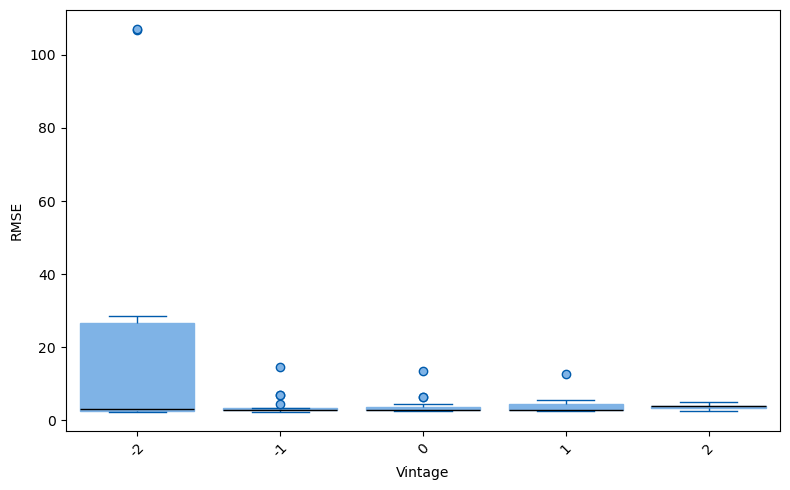

In [9]:
df = performance_table.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

# If you want a specific order, define it here; otherwise seaborn will infer it.
# order = sorted(df['Publication lag'].unique())
order = None

sns.boxplot(
    data=df,
    x='Vintage',
    y='RMSE',
    order=order,
    ax=ax,
    boxprops=dict(color=idb_light_blue),
    whiskerprops=dict(color=idb_blue),
    capprops=dict(color=idb_blue),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor=idb_light_blue, markeredgecolor=idb_blue,
                    marker='o', markersize=6)
)

ax.set_title("")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Same boxplot with mean markers added.** The dot in each box shows the average RMSE for that publication lag, making it easier to compare central tendency across vintages.

c:\Users\guerr\anaconda3\envs\nwcst\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


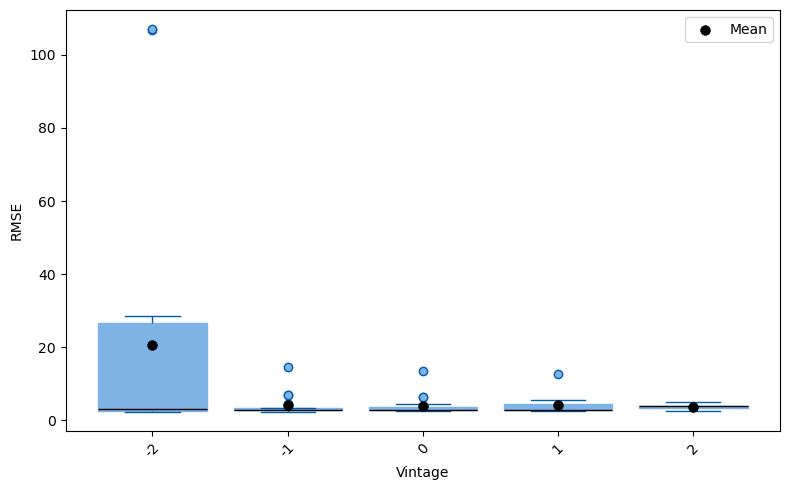

In [10]:
df = performance_table.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

# If you want a specific order, define it here; otherwise seaborn will infer it.
# order = sorted(df['Publication lag'].unique())
order = None

sns.boxplot(
    data=df,
    x='Vintage',
    y='RMSE',
    order=order,
    ax=ax,
    boxprops=dict(color=idb_light_blue),
    whiskerprops=dict(color=idb_blue),
    capprops=dict(color=idb_blue),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor=idb_light_blue, markeredgecolor=idb_blue,
                    marker='o', markersize=6)
)

# Get the actual category order used on the axis (this is key)
cats = [t.get_text() for t in ax.get_xticklabels()]

# Means computed in the same category space as the plot
means = df.groupby('Vintage', dropna=False)['RMSE'].mean()

# Map tick labels -> x positions
xpos = np.arange(len(cats))

# Overlay means (match tick labels carefully)
ymeans = []
for c in cats:
    # Try direct label
    if c in means.index:
        ymeans.append(means.loc[c])
        continue
    # Try numeric label -> numeric index match (common when lag is int/float)
    try:
        cnum = float(c)
        hit = None
        for idx in means.index:
            try:
                if float(idx) == cnum:
                    hit = means.loc[idx]
                    break
            except Exception:
                pass
        ymeans.append(hit)
    except Exception:
        ymeans.append(None)

# Plot only the ones we found
mask = [v is not None and np.isfinite(v) for v in ymeans]
ax.scatter(
    xpos[mask],
    np.array(ymeans, dtype=float)[mask],
    color='black',
    marker='o',
    s=50,
    zorder=10,
    edgecolor='k',
    linewidth=0.4,
    label='Mean'
)

# Clean legend (only "Mean" once)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

ax.set_title("")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Histogram: distribution of errors

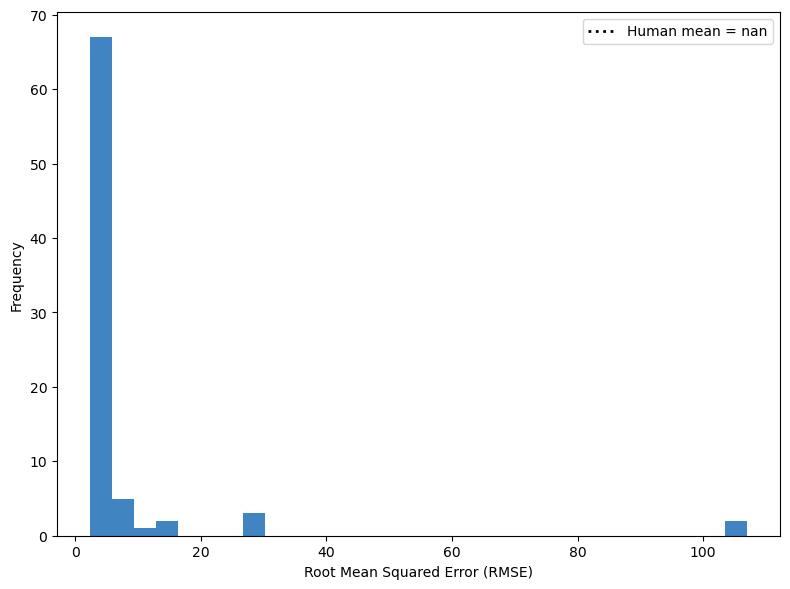

In [11]:
human_mean = performance_table[performance_table['spec']=='human1']['RMSE'].mean()

plt.figure(figsize=(8, 6))

# Plot with Seaborn, no edge lines
sns.histplot(performance_table['RMSE'], bins=30, kde=False, color=idb_blue, edgecolor=None)

# Median line
plt.axvline(human_mean, color='black', linestyle=':', linewidth=2, label=f'Human mean = {human_mean:.2f}')

plt.title("")
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

**Filter out extreme outliers using the vintage mean**

In [12]:
spec_rmse_mean = pd.DataFrame(performance_table.groupby('Vintage')['RMSE'].median())
spec_rmse_mean = spec_rmse_mean.rename(columns={'RMSE': 'threshold'})
spec_rmse_mean

,threshold
Vintage,
-2,3.240498
-1,2.910639
0,2.886124
1,2.972860
2,3.860037


**Apply the outlier filter and redraw the histogram.** Models whose RMSE exceeds the vintage-specific median are dropped. The histogram now shows the cleaned error distribution alongside the human-forecaster benchmark.

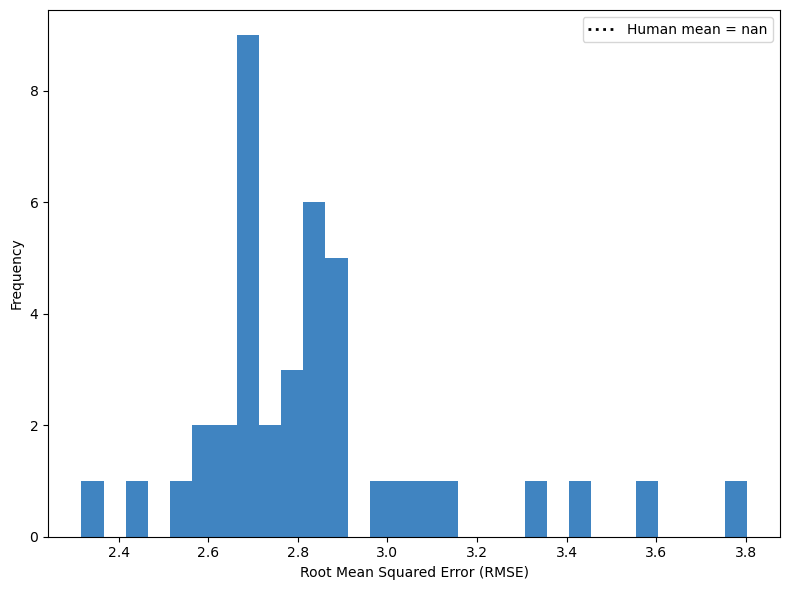

In [13]:
performance_table = performance_table.merge(spec_rmse_mean, on='Vintage', how='left')

# ++++++++++++++++++++++++++++++++++++++++++++++++++++
# ++++++++++++++++++++++++++++++++++++++++++++++++++++
filtered = performance_table[performance_table['RMSE'] < performance_table['threshold']]
# ++++++++++++++++++++++++++++++++++++++++++++++++++++
# ++++++++++++++++++++++++++++++++++++++++++++++++++++


human_mean = performance_table[performance_table['spec']=='human1']['RMSE'].mean()

plt.figure(figsize=(8, 6))

# Plot with Seaborn, no edge lines
sns.histplot(filtered['RMSE'], bins=30, kde=False, color=idb_blue, edgecolor=None)

# Median line
plt.axvline(human_mean, color='black', linestyle=':', linewidth=2, label=f'Human mean = {human_mean:.2f}')

plt.title("")
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Histogram conditional on publication lag

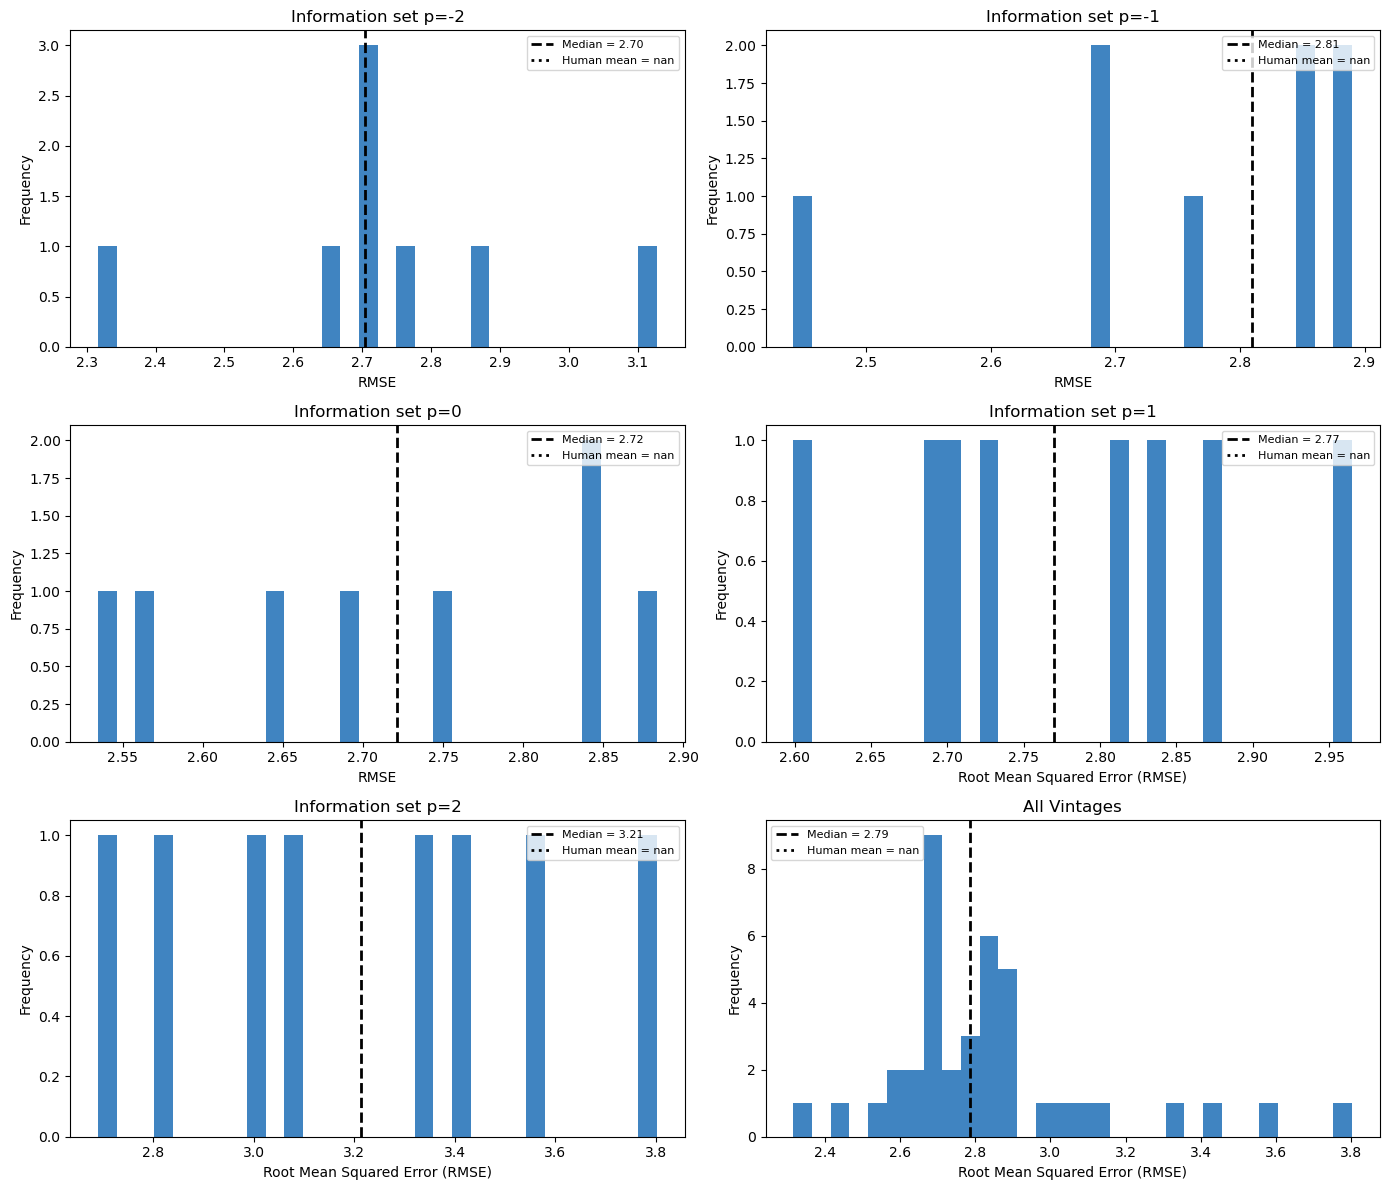

In [14]:
human_means = (
    performance_table[performance_table['spec'] == 'human1']
    .groupby('Vintage')
    .mean(numeric_only=True)
)

# Mapping of vintages
lags = {
    -2: 'two_back',
    -1: 'one_back',
     0: 'zero_back',
     1: 'one_ahead',
     2: 'two_ahead'
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12), sharex=False, sharey=False)
axes = axes.flatten()

# ------------------------------------------------
# Loop over each vintage and plot histogram
for i, (V, N) in enumerate(lags.items()):
    ax = axes[i]

    # Filter data for this vintage
    subset = filtered[filtered.index == V]

    # Histogram
    sns.histplot(subset['RMSE'], bins=30, kde=False, color=idb_blue, edgecolor=None, ax=ax)

    # Median line
    rmse_median = subset['RMSE'].median()
    ax.axvline(rmse_median, color='black', linestyle='dashed', linewidth=2, label=f'Median = {rmse_median:.2f}')

    # Human benchmark
    human_mean = human_means[human_means.index==V]['RMSE'].mean()
    ax.axvline(human_mean, color='black', linestyle=':', linewidth=2, label=f'Human mean = {human_mean:.2f}')

    # Titles
    ax.set_title(f'Information set p={V}', fontsize=12)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8, loc='upper right')

# ------------------------------------------------
# Last panel: pooled distribution
ax = axes[-1]
sns.histplot(filtered['RMSE'], bins=30, kde=False, color=idb_blue, edgecolor=None, ax=ax)

rmse_median = filtered['RMSE'].median()
ax.axvline(rmse_median, color='black', linestyle='dashed', linewidth=2, label=f'Median = {rmse_median:.2f}')

human_mean = performance_table[performance_table['spec'] == 'human1']['RMSE'].mean()
ax.axvline(human_mean, color='black', linestyle=':', linewidth=2, label=f'Human mean = {human_mean:.2f}')

ax.set_title('All Vintages', fontsize=12)
ax.set_ylabel('Frequency')
ax.legend(fontsize=8, loc='upper left')

# ------------------------------------------------
# X-labels on bottom row
for ax in axes[-3:]:
    ax.set_xlabel("Root Mean Squared Error (RMSE)")

plt.tight_layout()
plt.show()

## Boxplot (outliers management)

c:\Users\guerr\anaconda3\envs\nwcst\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


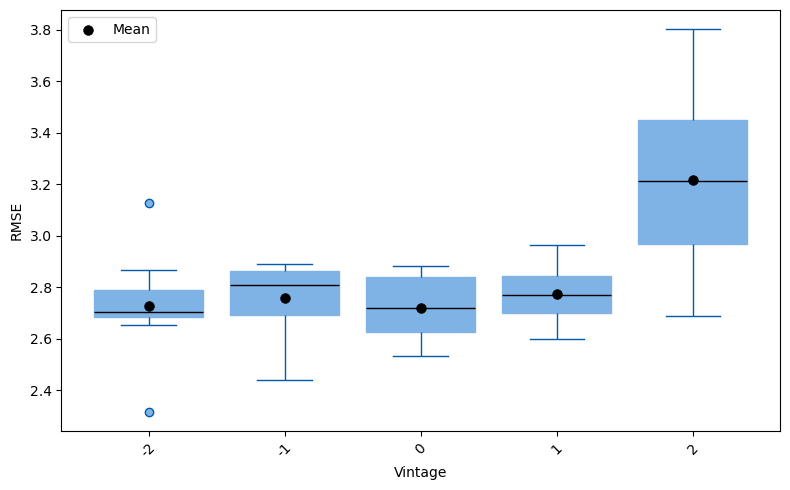

In [15]:
# First we define reference points
human_p = performance_table[performance_table['spec']=='human1']
human_p = human_p.groupby(human_p.index)['RMSE'].mean()
all_means = filtered.groupby(filtered.index)['RMSE'].mean()


fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=filtered.reset_index(),
    x='Vintage',
    y='RMSE',
    ax=ax,
    boxprops=dict(color=idb_light_blue),
    whiskerprops=dict(color=idb_blue),
    capprops=dict(color=idb_blue),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor=idb_light_blue, markeredgecolor=idb_blue, marker='o', markersize=6)
)

# Ensure the figure is rendered so tick labels are available
fig.canvas.draw()   # <- important

xticks = ax.get_xticks()
xtlabels = [t.get_text() for t in ax.get_xticklabels()]

# compute means (keep original dtype)
all_means = filtered.reset_index().groupby('Vintage')['RMSE'].mean()

def find_mean_for_label(lbl):
    # direct match
    if lbl in all_means.index:
        return all_means.loc[lbl]
    # try numeric match
    try:
        lbl_num = float(lbl)
        for idx in all_means.index:
            try:
                if float(idx) == lbl_num:
                    return all_means.loc[idx]
            except Exception:
                continue
    except Exception:
        pass
    # fallback: match by string representation
    for idx in all_means.index:
        if str(idx) == lbl:
            return all_means.loc[idx]
    return None

# plot mean markers aligned to the xtick positions
for i, lbl in enumerate(xtlabels):
    m = find_mean_for_label(lbl)
    if m is not None:
        ax.scatter(xticks[i], m, color='black', marker='o', s=50, zorder=10,
                   label='Mean' if i == 0 else "", edgecolor='k', linewidth=0.4)

# overlay human points: match similarly
for i, vintage in enumerate(human_p.index):
    # try to find which xtick corresponds
    for j, lbl in enumerate(xtlabels):
        try:
            if str(vintage) == lbl or float(vintage) == float(lbl):
                ax.scatter(xticks[j], human_p[vintage], color='black', marker='v', s=50,
                           label='Human' if i == 0 else "")
                break
        except Exception:
            if str(vintage) == lbl:
                ax.scatter(xticks[j], human_p[vintage], color='black', marker='v', s=50,
                           label='Human' if i == 0 else "")
                break

# clean legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys())

ax.set_title("")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


# Nowcast outputs:

## Results/RMSE merge

Filter out results from under-performing models

In [16]:
# -----------------------------------------------
# Reshape results to long format
df = results_table.reset_index().melt(
    id_vars=["date", 'spec', 'estimator'],
    value_vars=["two_back", "one_back", "zero_back", "one_ahead", "two_ahead"],
    var_name="horizon",
    value_name="value"
)

# Make Vintage column based on horizon -2, -1, 0, 1, 2
df['Vintage'] = df['horizon'].map({
    'two_back': -2,
    'one_back': -1,
    'zero_back': 0,
    'one_ahead': 1,
    'two_ahead': 2
})
df

,date,spec,estimator,horizon,value,Vintage
0,2023-06-01,lars19,OLS,two_back,0.142740,-2
1,2023-09-01,lars19,OLS,two_back,0.362125,-2
2,2023-12-01,lars19,OLS,two_back,4.725324,-2
3,2024-03-01,lars19,OLS,two_back,-73.690762,-2
4,2024-06-01,lars19,OLS,two_back,1.938280,-2
...,...,...,...,...,...,...
955,2025-03-01,lars44,LSTM,two_ahead,0.571354,2
956,2025-06-01,lars44,LSTM,two_ahead,0.920585,2
957,2025-09-01,lars44,LSTM,two_ahead,1.004162,2
958,2025-12-01,lars44,LSTM,two_ahead,1.189423,2


**Attach each model's RMSE to its nowcast values.** We join the performance table onto the long-format results so that every prediction row carries the corresponding model error — needed for the quality filter below.

In [17]:
p = performance_table.reset_index()
results_w = (
    df  # safe even if index is unnamed
    .rename(columns=str.strip)
    .merge(
        p.rename(columns=str.strip)[['Vintage','spec','estimator','RMSE']],
        on=['Vintage','spec','estimator'],
        how='left'
    )
)
results_w

,date,spec,estimator,horizon,value,Vintage,RMSE
0,2023-06-01,lars19,OLS,two_back,0.142740,-2,28.649759
1,2023-09-01,lars19,OLS,two_back,0.362125,-2,28.649759
2,2023-12-01,lars19,OLS,two_back,4.725324,-2,28.649759
3,2024-03-01,lars19,OLS,two_back,-73.690762,-2,28.649759
4,2024-06-01,lars19,OLS,two_back,1.938280,-2,28.649759
...,...,...,...,...,...,...,...
955,2025-03-01,lars44,LSTM,two_ahead,0.571354,2,2.822476
956,2025-06-01,lars44,LSTM,two_ahead,0.920585,2,2.822476
957,2025-09-01,lars44,LSTM,two_ahead,1.004162,2,2.822476
958,2025-12-01,lars44,LSTM,two_ahead,1.189423,2,2.822476


**Keep only the better-performing models.** For each forecasting horizon we discard models whose RMSE is above the horizon average, retaining only those that have predicted well historically.

In [18]:
mean_rmse = results_w.groupby('Vintage')['RMSE'].mean()

# Keep rows with RMSE <= Vintage-specific mean
filtered = results_w[
    results_w['RMSE'] <= results_w['Vintage'].map(mean_rmse)
]
filtered

,date,spec,estimator,horizon,value,Vintage,RMSE
12,2023-06-01,lars19,OLSR,two_back,0.838279,-2,4.018301
13,2023-09-01,lars19,OLSR,two_back,0.522094,-2,4.018301
14,2023-12-01,lars19,OLSR,two_back,0.977491,-2,4.018301
15,2024-03-01,lars19,OLSR,two_back,-9.952727,-2,4.018301
16,2024-06-01,lars19,OLSR,two_back,0.694706,-2,4.018301
...,...,...,...,...,...,...,...
955,2025-03-01,lars44,LSTM,two_ahead,0.571354,2,2.822476
956,2025-06-01,lars44,LSTM,two_ahead,0.920585,2,2.822476
957,2025-09-01,lars44,LSTM,two_ahead,1.004162,2,2.822476
958,2025-12-01,lars44,LSTM,two_ahead,1.189423,2,2.822476


## Ridge plot

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = filtered[['date', 'horizon', 'Vintage', 'value']]
observed = pd.DataFrame(results_table['actuals'].groupby(results_table.index).mean())
actuals_dict = observed['actuals'].to_dict()
df

,date,horizon,Vintage,value
12,2023-06-01,two_back,-2,0.838279
13,2023-09-01,two_back,-2,0.522094
14,2023-12-01,two_back,-2,0.977491
15,2024-03-01,two_back,-2,-9.952727
16,2024-06-01,two_back,-2,0.694706
...,...,...,...,...
955,2025-03-01,two_ahead,2,0.571354
956,2025-06-01,two_ahead,2,0.920585
957,2025-09-01,two_ahead,2,1.004162
958,2025-12-01,two_ahead,2,1.189423


**Draw the ridge plot.** Each row is one quarter; the colored curves show how the nowcast values are spread across models for each horizon. This reveals how much uncertainty exists at different information sets.

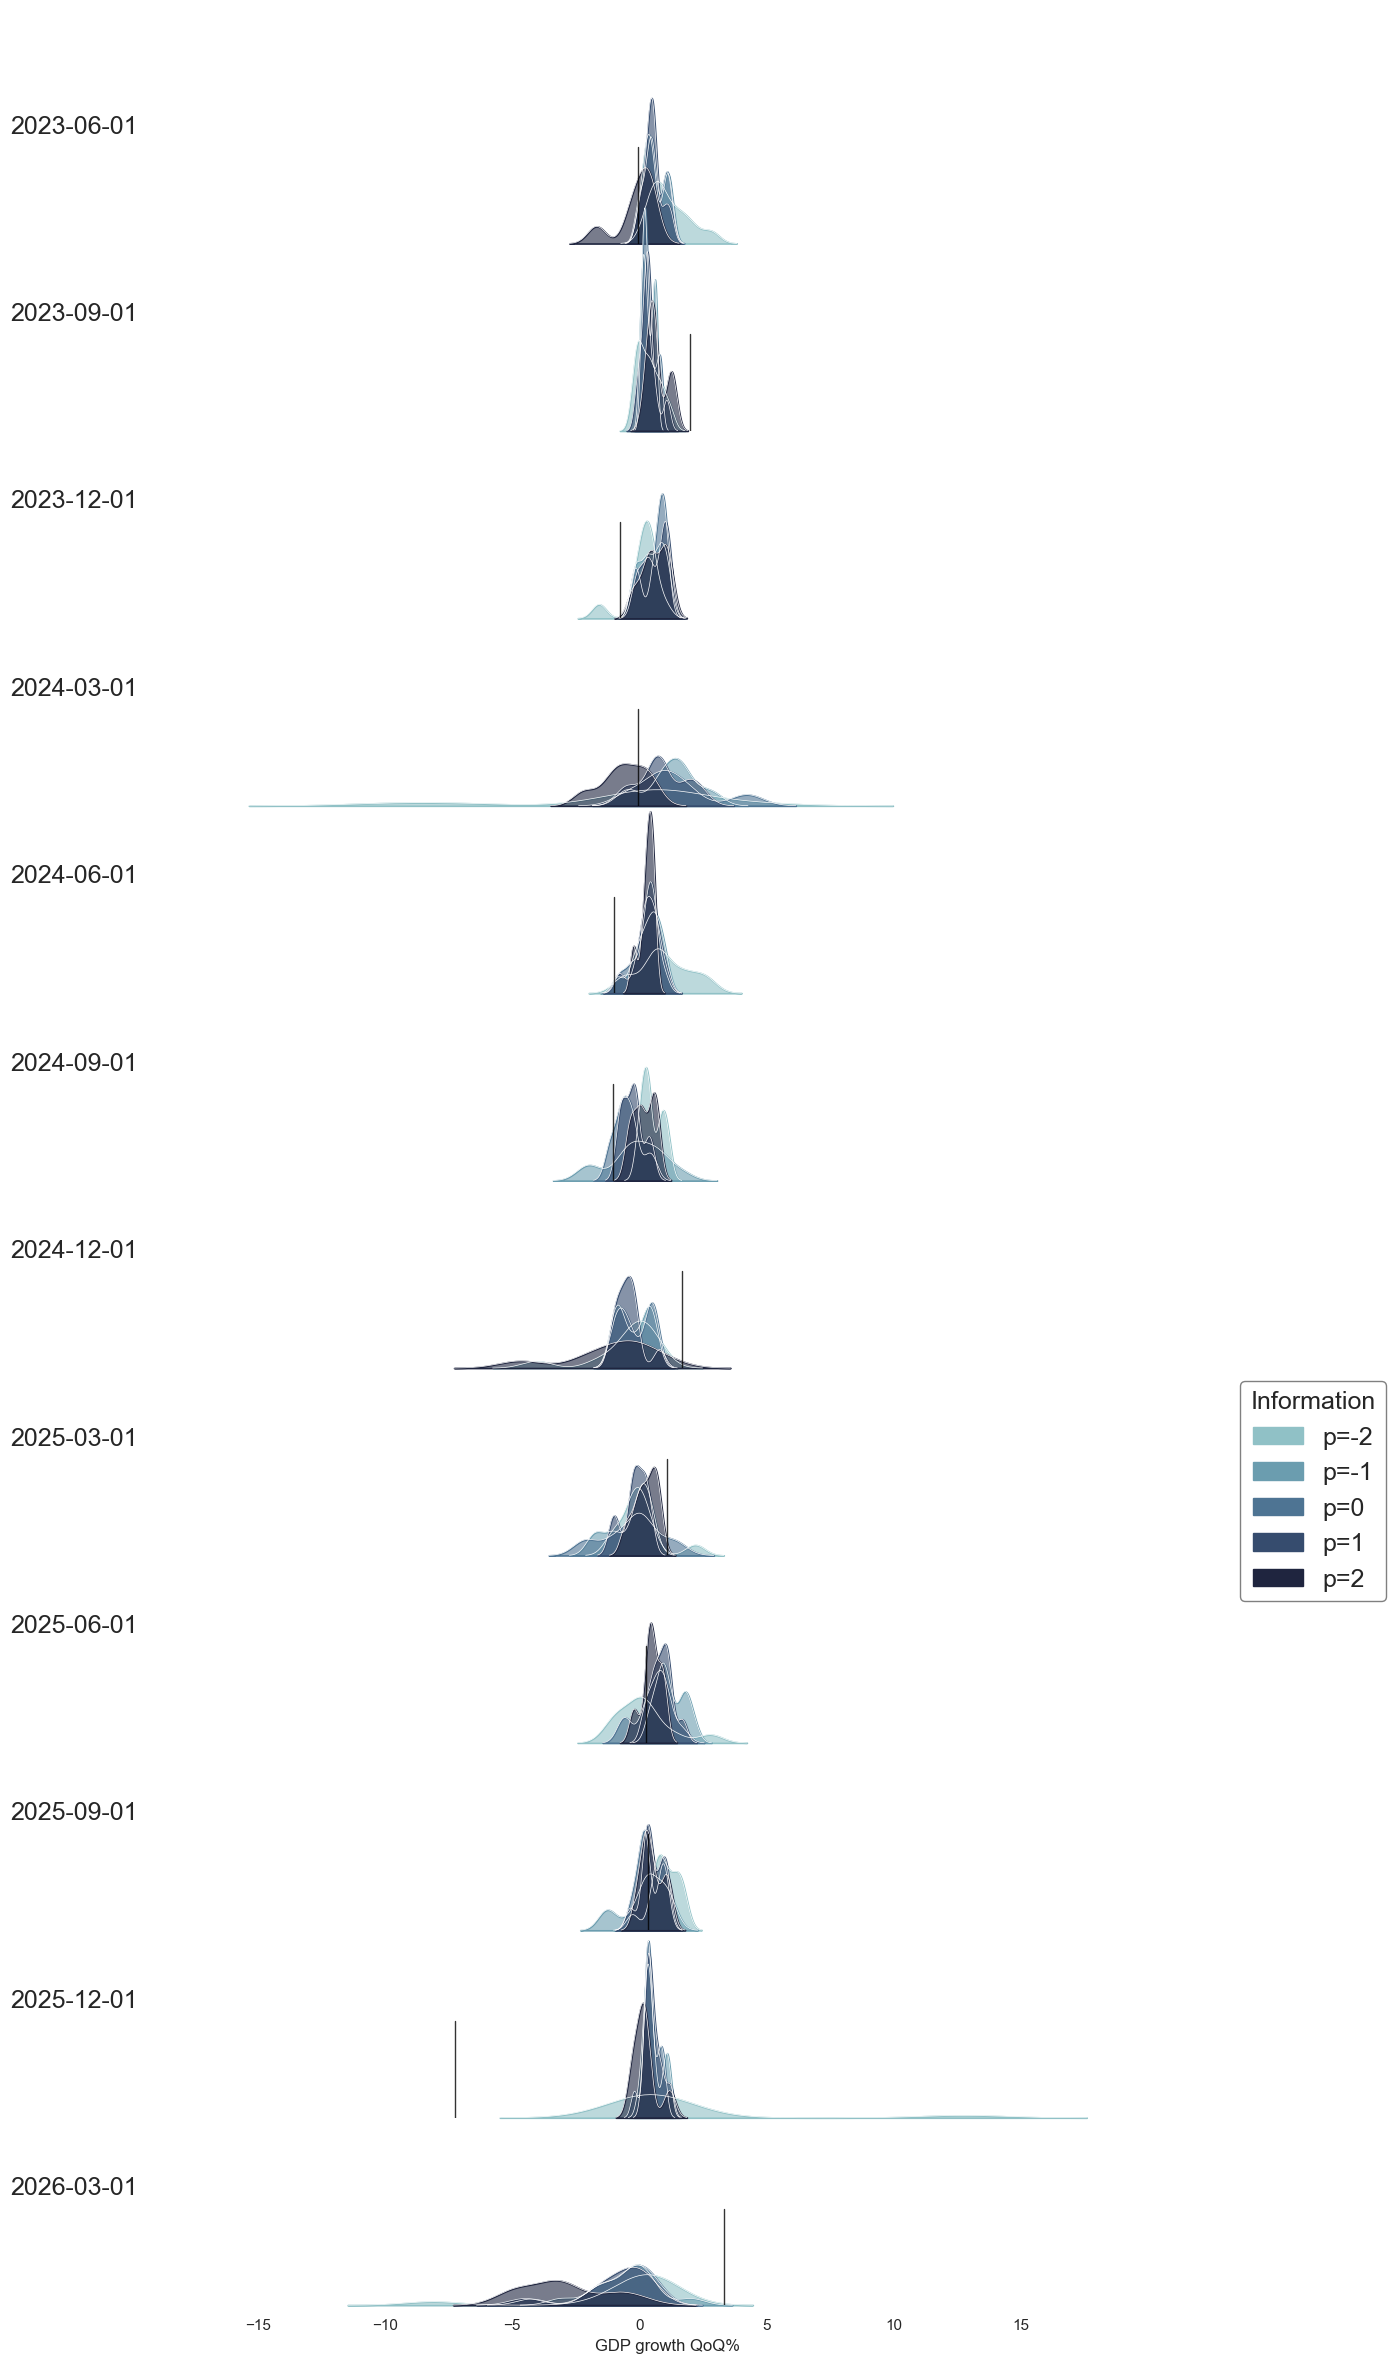

In [20]:
# Mock data to make the code runnable
dates = df["date"].unique()
horizons = ["two_back", "one_back", "zero_back", "one_ahead", "two_ahead"]
data = []
for date in dates:
    for horizon in horizons:
        # Create different distribution shapes to make the plot more interesting
        values = df[(df['date']==date) & (df['horizon']==horizon)].value
        data.extend([(date, horizon, v) for v in values])

df = pd.DataFrame(data, columns=["date", "horizon", "value"])

horizon_labels = {
    "two_back": "p=-2",
    "one_back": "p=-1",
    "zero_back": "p=0",
    "one_ahead": "p=1",
    "two_ahead": "p=2"
}
df["horizon"] = df["horizon"].map(horizon_labels)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Generate a range of colors for the horizons
horizons_unique = df["horizon"].unique()
n_horizons = len(horizons_unique)
pal = sns.cubehelix_palette(n_horizons, rot=-.25, light=.7)

# The fix is to add sharey=False
g = sns.FacetGrid(
    df,  
    row="date",  
    hue="horizon",  
    aspect=5,  
    height=2,  
    palette=pal,
    sharey=True  # This is the key change
)

# KDE distributions
g.map(
    sns.kdeplot,  
    "value",  
    bw_adjust=0.7,  
    clip_on=False,  
    fill=True,  
    alpha=0.6,  
    linewidth=1.2,
    common_norm=True
)

# Contour lines
g.map(
    sns.kdeplot,  
    "value",  
    bw_adjust=0.7,  
    clip_on=False,  
    color="w",  
    lw=0.5
)

# Adjust spacing between ridges
g.fig.subplots_adjust(hspace=-0.2)

# Y-axis labels as dates, remove density scale
for ax, date in zip(g.axes.flat, df["date"].unique()):
    ax.set_ylabel(date.strftime("%Y-%m-%d"), rotation=0, labelpad=50, ha="right", va="center", fontsize=18)
    ax.set_yticks([])
    ax.axhline(y=0, color="gray", lw=0.6, ls="--", alpha=0.7)

# Add observed (example without results_table)
# Loop through the axes and sorted dates to plot the correct 'actual' value
sorted_dates = sorted(df["date"].unique())
for ax, date in zip(g.axes.flat, sorted_dates):
    actual_value = actuals_dict.get(date)
    if actual_value is not None:
        # Create a line with y-coordinates from 0.1 to 0.9 of the axes height,
        # but with the x-coordinate in data units.
        line = plt.Line2D(
            [actual_value, actual_value], # x-coordinates in data units
            [0, 0.9],                   # y-coordinates in axes units
            transform=ax.transData,       # This is the correct transform object
            color='black', linestyle='-', lw=1, alpha=0.8
        )
        # Add the line to the current axes.
        ax.add_line(line)
     
# Cleanup axes
g.set(xlabel="GDP growth QoQ%")
g.set_titles("")
g.despine(bottom=True, left=True)

# Custom white legend
palette_dict = dict(zip(horizons_unique, pal))
handles = [mpatches.Patch(color=palette_dict[h], label=h) for h in horizons_unique]
plt.legend(
    handles=handles,  
    title="Information",  
    title_fontsize=18,  
    fontsize=18,  
    bbox_to_anchor=(1.2, 4),  
    loc="upper center",
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=1
)

# Save and show
plt.show()

## Weighted Nowcast

We will weight the nowcast by the inverse of the RMSE. Effectively, we will compute:

$$
\hat{v}
= \frac{\sum_{i=1}^{N} w_i \, v_i}{\sum_{i=1}^{N} w_i}
= \frac{\sum_{i=1}^{N} \dfrac{v_i}{\mathrm{RMSE}_i}}
       {\sum_{i=1}^{N} \dfrac{1}{\mathrm{RMSE}_i}}
$$

We can also estimate a weighted confidence interval using the same weights.

$$
\mathrm{SE}(\hat{v})
= \frac{1}{\sqrt{\sum_{i=1}^{N} w_i}}
= \left( \sum_{i=1}^{N} \frac{1}{\mathrm{RMSE}_i} \right)^{-1/2}
$$

$$
\hat{v} \pm 1.96 \cdot \mathrm{SE}(\hat{v})
$$



In [21]:
filtered = filtered.copy()
filtered['date'] = pd.to_datetime(filtered['date'])
filtered['weight'] = 1 / filtered['RMSE']
filtered

,date,spec,estimator,horizon,value,Vintage,RMSE,weight
12,2023-06-01,lars19,OLSR,two_back,0.838279,-2,4.018301,0.248861
13,2023-09-01,lars19,OLSR,two_back,0.522094,-2,4.018301,0.248861
14,2023-12-01,lars19,OLSR,two_back,0.977491,-2,4.018301,0.248861
15,2024-03-01,lars19,OLSR,two_back,-9.952727,-2,4.018301,0.248861
16,2024-06-01,lars19,OLSR,two_back,0.694706,-2,4.018301,0.248861
...,...,...,...,...,...,...,...,...
955,2025-03-01,lars44,LSTM,two_ahead,0.571354,2,2.822476,0.354299
956,2025-06-01,lars44,LSTM,two_ahead,0.920585,2,2.822476,0.354299
957,2025-09-01,lars44,LSTM,two_ahead,1.004162,2,2.822476,0.354299
958,2025-12-01,lars44,LSTM,two_ahead,1.189423,2,2.822476,0.354299


**Pull out the observed (actual) GDP values.** These are the true outcomes the models were trying to predict — we will compare nowcasts against them in the next steps.

In [22]:
df = results_table[['actuals']]
df = df.groupby('date').mean()
df.index = pd.to_datetime(df.index)
df

,actuals
date,
2023-06-01,-0.066758
2023-09-01,1.988200
2023-12-01,-0.778219
2024-03-01,-0.054704
2024-06-01,-0.997453
2024-09-01,-1.055556
2024-12-01,1.691583
2025-03-01,1.086629
2025-06-01,0.255034


**Compute the RMSE-weighted average nowcast for the earliest horizon (two quarters before release).** Models with lower historical errors receive more weight, so the combined forecast relies more on models that have been accurate in the past.

In [23]:
# ---------------------------------------------------
V = -2
N = "two_back"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')


df = df.merge(weighted, left_index=True, right_index=True, how='left')
df

,actuals,two_back
date,,
2023-06-01,-0.066758,1.118752
2023-09-01,1.988200,0.345499
2023-12-01,-0.778219,0.215098
2024-03-01,-0.054704,-0.618159
2024-06-01,-0.997453,0.877600
2024-09-01,-1.055556,0.421827
2024-12-01,1.691583,-0.288345
2025-03-01,1.086629,-0.130189
2025-06-01,0.255034,0.075019


**Repeat the weighted average for the remaining four forecasting horizons**, adding each as a new column to the table.

In [24]:
# ---------------------------------------------------
V = -1
N = "one_back"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')

df = df.merge(weighted, left_index=True, right_index=True, how='left')

# ---------------------------------------------------
V = 0
N = "zero_back"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')

df = df.merge(weighted, left_index=True, right_index=True, how='left')

# ---------------------------------------------------
V = 1
N = "one_ahead"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')

df = df.merge(weighted, left_index=True, right_index=True, how='left')

# ---------------------------------------------------
V = 2
N = "two_ahead"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')

df = df.merge(weighted, left_index=True, right_index=True, how='left')

df

,actuals,two_back,one_back,zero_back,one_ahead,two_ahead
date,,,,,,
2023-06-01,-0.066758,1.118752,0.583341,0.581724,0.526723,-0.070080
2023-09-01,1.988200,0.345499,0.346826,0.370802,0.366704,0.691500
2023-12-01,-0.778219,0.215098,0.497992,0.587382,0.602238,0.575753
2024-03-01,-0.054704,-0.618159,1.258379,1.365282,0.909415,-0.567704
2024-06-01,-0.997453,0.877600,0.315028,0.248993,0.290724,0.284769
2024-09-01,-1.055556,0.421827,-0.105612,-0.438465,-0.259509,0.181779
2024-12-01,1.691583,-0.288345,-0.228100,-0.190624,-0.426483,-1.032538
2025-03-01,1.086629,-0.130189,-0.349497,-0.250278,-0.193459,0.210064
2025-06-01,0.255034,0.075019,1.192427,0.606277,0.872836,0.469649


Alternatively... a loop, from start:

In [25]:
horizons = {
    'two_back': -2,
    'one_back': -1,
    'zero_back': 0,
    'one_ahead': 1,
    'two_ahead': 2
}

filtered = filtered.copy()
filtered['date'] = pd.to_datetime(filtered['date'])
filtered['weight'] = 1 / filtered['RMSE']

df = results_table[['actuals']]
df = df.groupby('date').mean()
df.index = pd.to_datetime(df.index)
df

,actuals
date,
2023-06-01,-0.066758
2023-09-01,1.988200
2023-12-01,-0.778219
2024-03-01,-0.054704
2024-06-01,-0.997453
2024-09-01,-1.055556
2024-12-01,1.691583
2025-03-01,1.086629
2025-06-01,0.255034


**Compact loop version: compute the RMSE-weighted average nowcast for all five horizons at once.** This replaces the step-by-step approach above and produces the same result more concisely.

In [26]:
horizons = {
    'two_back': -2,
    'one_back': -1,
    'zero_back': 0,
    'one_ahead': 1,
    'two_ahead': 2
}

for N, V in horizons.items():
    d = filtered.loc[filtered['Vintage'] == V]

    weighted = (
        (d['value'] * d['weight']).groupby(d['date']).sum()
        / d.groupby(d['date'])['weight'].sum()
    ).reset_index(name=N).set_index('date')

    df = df.merge(weighted, left_index=True, right_index=True, how='left')

df


,actuals,two_back,one_back,zero_back,one_ahead,two_ahead
date,,,,,,
2023-06-01,-0.066758,1.118752,0.583341,0.581724,0.526723,-0.070080
2023-09-01,1.988200,0.345499,0.346826,0.370802,0.366704,0.691500
2023-12-01,-0.778219,0.215098,0.497992,0.587382,0.602238,0.575753
2024-03-01,-0.054704,-0.618159,1.258379,1.365282,0.909415,-0.567704
2024-06-01,-0.997453,0.877600,0.315028,0.248993,0.290724,0.284769
2024-09-01,-1.055556,0.421827,-0.105612,-0.438465,-0.259509,0.181779
2024-12-01,1.691583,-0.288345,-0.228100,-0.190624,-0.426483,-1.032538
2025-03-01,1.086629,-0.130189,-0.349497,-0.250278,-0.193459,0.210064
2025-06-01,0.255034,0.075019,1.192427,0.606277,0.872836,0.469649


## Graph results

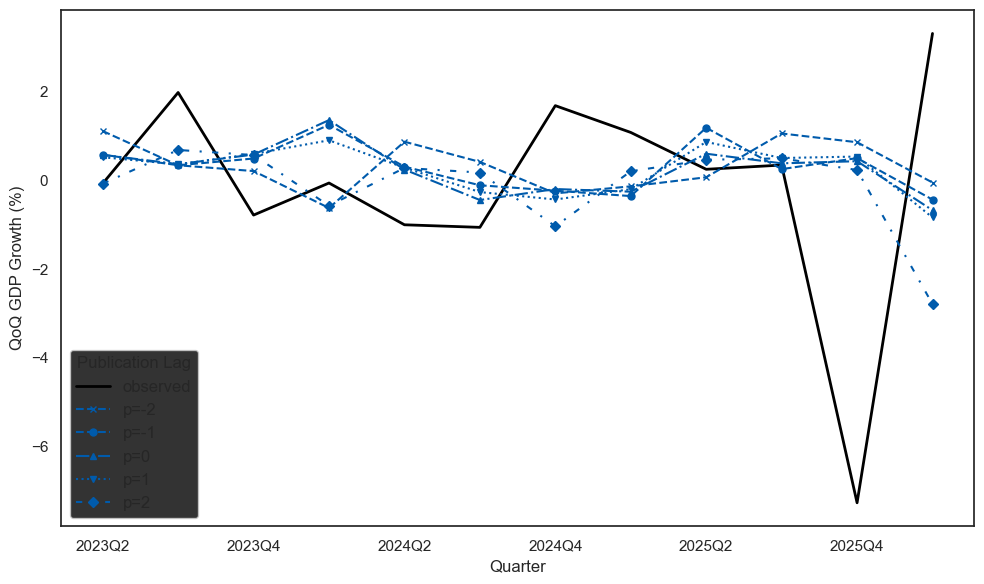

In [27]:
plot_df = df.rename(columns={
    'actuals': 'observed',
    'two_back': 'p=-2',
    'one_back': 'p=-1',
    'zero_back': 'p=0',
    'one_ahead': 'p=1',
    'two_ahead': 'p=2'
})
plot_df.index = pd.PeriodIndex(plot_df.index, freq='Q').astype(str)
fig, ax = plt.subplots(figsize=(10,6))

# Plot 'observed' as a black dashed line, no marker
plot_df['observed'].plot(
    ax=ax, color='black', linestyle='-', linewidth=2, label='observed'
)

# Define line styles and markers for other lines
line_styles = ['--', '--', '-.', ':', (0, (3, 5, 1, 5))]  # various dash styles
markers = ['x', 'o', '^', 'v', 'D']  # circle, square, triangle up/down, diamond

# Plot the rest with unique line styles and markers
for idx, col in enumerate(['p=-2', 'p=-1', 'p=0', 'p=1', 'p=2']):
    plot_df[col].plot(
        ax=ax,
        color=idb_blue,
        linestyle=line_styles[idx],
        marker=markers[idx],
        linewidth=1.5,
        markersize=5,
        label=col
    )

# Labels and grid
ax.set_title('')
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('QoQ GDP Growth (%)', fontsize=12)
ax.legend(title='Publication Lag', fontsize=12, title_fontsize=12)
plt.tight_layout()

plt.show()

## Weighted Nowcast with Confidence Intervals

In [28]:
df = results_table[['actuals']].groupby('date').mean()
df

,actuals
date,
2023-06-01,-0.066758
2023-09-01,1.988200
2023-12-01,-0.778219
2024-03-01,-0.054704
2024-06-01,-0.997453
2024-09-01,-1.055556
2024-12-01,1.691583
2025-03-01,1.086629
2025-06-01,0.255034


**Compute weighted average nowcasts and 95% confidence intervals for all horizons.** For each horizon we calculate the weighted mean, its standard error (SE), and the interval mean +/- 1.96 x SE.

In [29]:
lags = {
    -2: 'two_back',
    -1: 'one_back',
     0: 'zero_back',
     1: 'one_ahead',
     2: 'two_ahead'
}

for V, N in lags.items():
    # Read and prepare results_table fresh in each loop
    New_Table = filtered.copy()
    d = New_Table.loc[New_Table['Vintage'] == V]

    g = d.groupby('date')

    meanN = (
        (d['value'] * d['weight']).groupby(d['date']).sum()
        / g['weight'].sum()
    ).rename(N)

    seN = (1 / np.sqrt(g['weight'].sum())).rename(f'se_{N}')

    weighted = pd.concat([meanN, seN], axis=1)

    # Compute 95% confidence interval bounds
    weighted[f'ci_lower_{N}'] = weighted[N] - 1.96 * weighted[f'se_{N}']
    weighted[f'ci_upper_{N}'] = weighted[N] + 1.96 * weighted[f'se_{N}']

    # Concatenate the new columns to the main df
    df = df.join(weighted[[N, f'se_{N}', f'ci_lower_{N}', f'ci_upper_{N}']])

df.index = pd.PeriodIndex(df.index, freq='Q').astype(str)
df

,actuals,two_back,se_two_back,ci_lower_two_back,ci_upper_two_back,one_back,se_one_back,ci_lower_one_back,ci_upper_one_back,zero_back,...,ci_lower_zero_back,ci_upper_zero_back,one_ahead,se_one_ahead,ci_lower_one_ahead,ci_upper_one_ahead,two_ahead,se_two_ahead,ci_lower_two_ahead,ci_upper_two_ahead
date,,,,,,,,,,,,,,,,,,,,,
2023Q2,-0.066758,1.118752,0.524424,0.090880,2.146624,0.583341,0.485625,-0.368483,1.535165,0.581724,...,-0.369234,1.532681,0.526723,0.532893,-0.517747,1.571193,-0.070080,0.666039,-1.375516,1.235356
2023Q3,1.988200,0.345499,0.524424,-0.682373,1.373371,0.346826,0.485625,-0.604998,1.298650,0.370802,...,-0.580156,1.321760,0.366704,0.532893,-0.677766,1.411174,0.691500,0.666039,-0.613935,1.996936
2023Q4,-0.778219,0.215098,0.524424,-0.812774,1.242970,0.497992,0.485625,-0.453833,1.449816,0.587382,...,-0.363576,1.538339,0.602238,0.532893,-0.442232,1.646708,0.575753,0.666039,-0.729683,1.881189
2024Q1,-0.054704,-0.618159,0.524424,-1.646031,0.409713,1.258379,0.485625,0.306555,2.210204,1.365282,...,0.414325,2.316240,0.909415,0.532893,-0.135055,1.953886,-0.567704,0.666039,-1.873139,0.737732
2024Q2,-0.997453,0.877600,0.524424,-0.150272,1.905471,0.315028,0.485625,-0.636796,1.266853,0.248993,...,-0.701964,1.199951,0.290724,0.532893,-0.753746,1.335194,0.284769,0.666039,-1.020666,1.590205
2024Q3,-1.055556,0.421827,0.524424,-0.606045,1.449699,-0.105612,0.485625,-1.057436,0.846212,-0.438465,...,-1.389423,0.512492,-0.259509,0.532893,-1.303980,0.784961,0.181779,0.666039,-1.123657,1.487215
2024Q4,1.691583,-0.288345,0.524424,-1.316217,0.739527,-0.228100,0.485625,-1.179925,0.723724,-0.190624,...,-1.141581,0.760334,-0.426483,0.532893,-1.470953,0.617987,-1.032538,0.666039,-2.337974,0.272898
2025Q1,1.086629,-0.130189,0.524424,-1.158061,0.897683,-0.349497,0.485625,-1.301321,0.602327,-0.250278,...,-1.201236,0.700679,-0.193459,0.532893,-1.237929,0.851011,0.210064,0.666039,-1.095372,1.515500
2025Q2,0.255034,0.075019,0.524424,-0.952853,1.102891,1.192427,0.485625,0.240603,2.144251,0.606277,...,-0.344681,1.557234,0.872836,0.532893,-0.171634,1.917306,0.469649,0.666039,-0.835787,1.775085


**Plot the weighted nowcast with confidence bands, one panel per horizon.** The shaded area shows the 95% interval around the weighted average, illustrating how uncertainty changes across forecasting horizons.

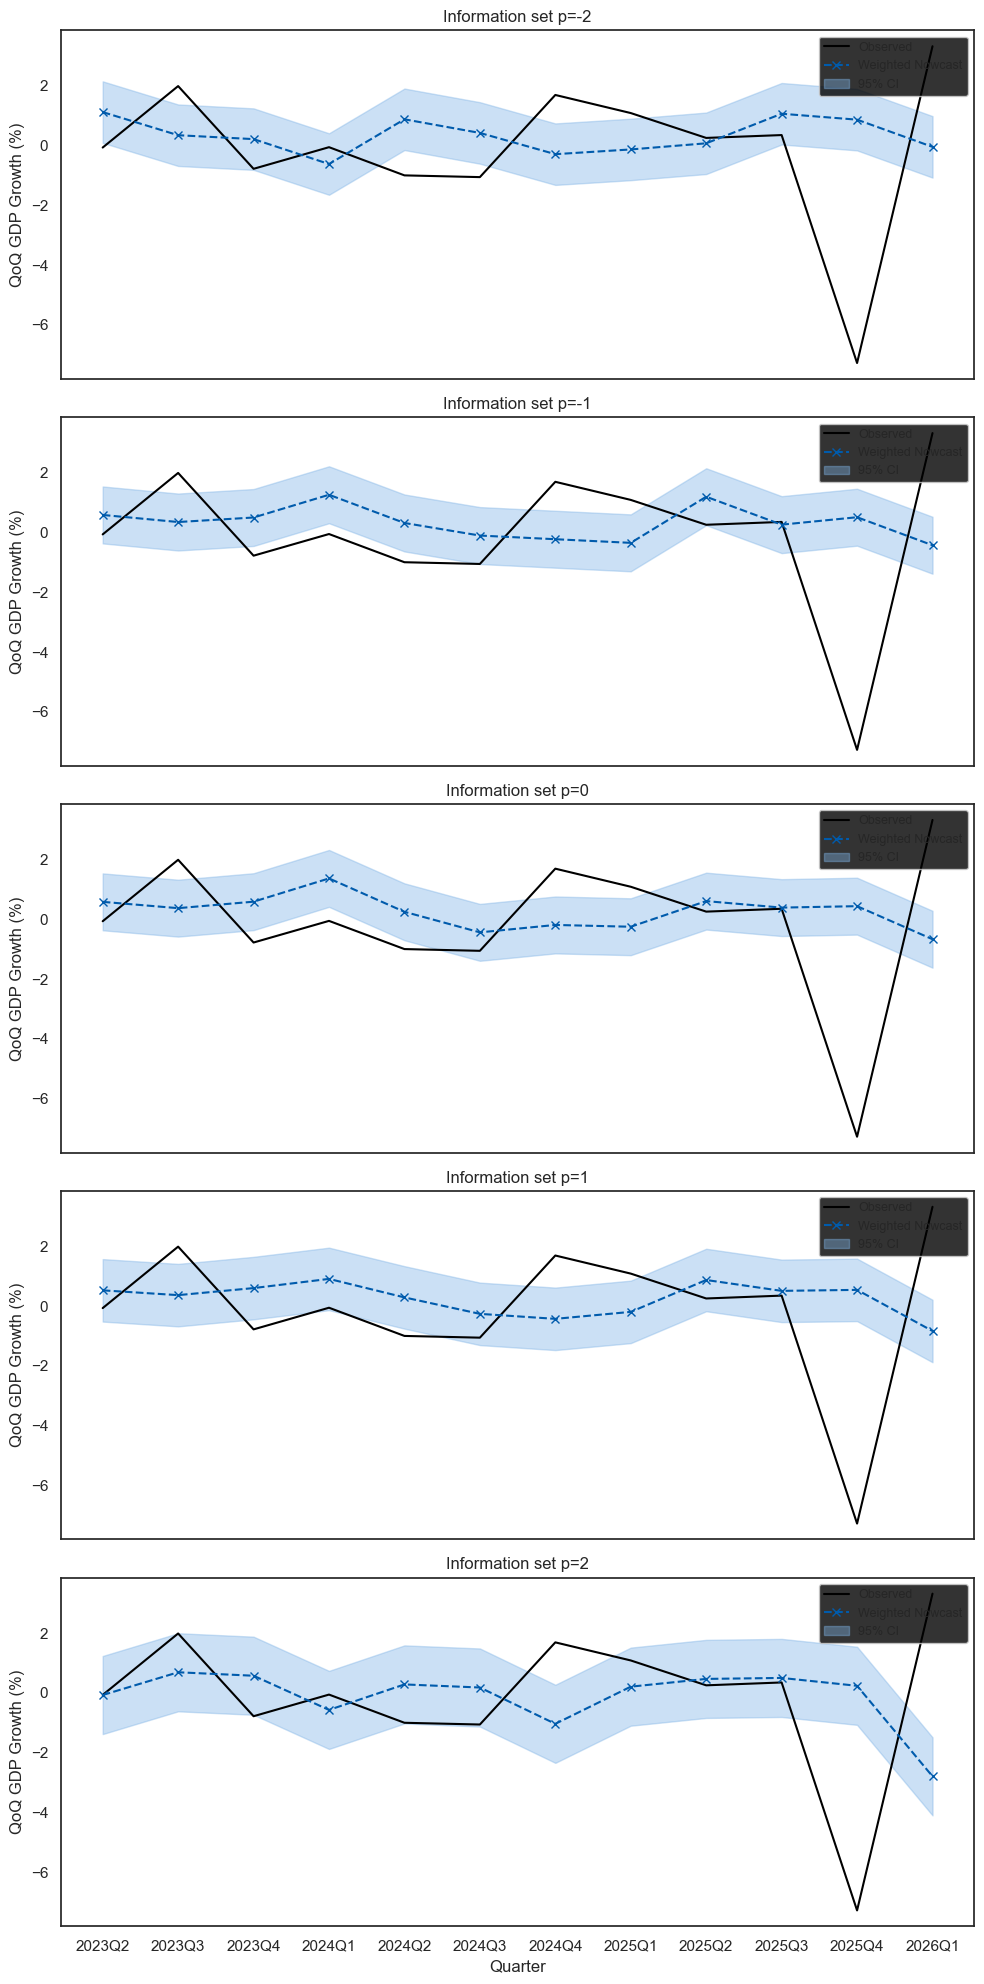

In [30]:
lags = {
    -2: 'two_back',
    -1: 'one_back',
     0: 'zero_back',
     1: 'one_ahead',
     2: 'two_ahead'
}

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20), sharex=True)

# ------------------------------------------------
# Loop over each vintage and plot
for ax, (V, N) in zip(axes, lags.items()):
    # Plot actuals
    ax.plot(df.index, df['actuals'], color='black', linestyle='-', label='Observed')
    
    # Plot nowcast for vintage N
    ax.plot(df.index, df[N], color=idb_blue, linestyle='--', marker='x', label=f'Weighted Nowcast')
    
    # Plot confidence interval as a shaded area
    ax.fill_between(
        df.index,
        df[f'ci_lower_{N}'],
        df[f'ci_upper_{N}'],
        color=idb_light_blue,
        alpha=0.4,
        label='95% CI'
    )
    
    # Titles and labels
    ax.set_title(f'Information set p={V}', fontsize=12)
    ax.set_ylabel('QoQ GDP Growth (%)')
    ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('Quarter')

plt.tight_layout()
plt.show()

# Out of sample

In [31]:
import os
import pandas as pd
import numpy as np
# date_str / PATH_* already come from the config loader at the top of the
# notebook; re-derived here so this section still runs on its own.
date_str    = cfg.DATE_STR
PATH_OUTPUT = os.path.join(P["output"], date_str)
PATH_DATA   = P["data"]


import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
'''
# Define the color scheme
idb_blue = "#005BAC"
idb_light_blue = "#7FB3E6"

# Load results
forecast_file = f"{date_str} 3_nwcst Tab fcst.xlsx"
performance_file = f"{date_str} 3_nwcst Tab perf.xlsx"
outofsample_file = f"{date_str} 3_nwcst Tab oos.xlsx"


results_table = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", index_col='date', parse_dates=True)
results_table.index = pd.to_datetime(results_table.index, format="%Y-%m-%d")
performance_table = pd.read_excel(f"{PATH_OUTPUT}/{performance_file}", parse_dates=True)
'''

forecast = filtered.copy()
forecast = forecast.dropna(how='all', axis=0)

performance = performance_table.copy()
performance = performance.dropna(how='any', axis=0)
performance['inv_rmse'] = 1 / (performance['RMSE']** 2)
performance['weight'] = performance.groupby('Vintage')['inv_rmse'].transform(lambda x: x / x.sum())

performance.reset_index(drop=False, inplace=True)


performance = performance[['Vintage', 'estimator', 'spec', 'weight']]
performance = performance.set_index('Vintage')
performance.index = performance.index.astype(str).str.replace("-2",'two_back')
performance.index = performance.index.astype(str).str.replace("-1",'one_back')
performance.index = performance.index.astype(str).str.replace("0",'zero_back')
performance.index = performance.index.astype(str).str.replace("1",'one_ahead')
performance.index = performance.index.astype(str).str.replace("2",'two_ahead')
performance = performance.reset_index()

performance.rename(columns={'Vintage': 'horizon'}, inplace=True)

#forecast = forecast.reset_index().melt(id_vars=['date', 'actuals', 'estimator', 'spec'],
#        value_vars=['two_back', 'one_back', 'zero_back', 'one_ahead', 'two_ahead'],
#        var_name='Vintage',
#        value_name='value')
forecast = forecast.drop(columns=['weight'], errors='ignore')
forecast = forecast.merge(performance, on=['horizon', 'estimator', 'spec'])
forecast = forecast.dropna(how='all', axis=0)
forecast = forecast[~forecast['value'].isna()]
forecast['value'] = ( ((1+ ( forecast['value']/100) )**4)-1 )*100
performance

,horizon,estimator,spec,weight
0,two_back,OLS,lars19,0.000960
1,one_back,OLS,lars19,0.002968
2,zero_back,OLS,lars19,0.003353
3,one_ahead,OLS,lars19,0.004309
4,two_ahead,OLS,lars19,0.041034
...,...,...,...,...
75,two_back,LSTM,lars44,0.107841
76,one_back,LSTM,lars44,0.076816
77,zero_back,LSTM,lars44,0.074603
78,one_ahead,LSTM,lars44,0.083034


**Build the out-of-sample summary statistics.** Load observed GDP growth, then compute the simple average, GBT-only, and RMSE-weighted nowcast for the most recent (out-of-sample) period.

In [32]:
data = pd.read_csv(f"{PATH_DATA}/data.csv", parse_dates=["date"], index_col='date')
data = data[['RGDP0000']].dropna()

from statsmodels.tsa.seasonal import seasonal_decompose
data['RGDP0000'] = seasonal_decompose(data['RGDP0000'].dropna(how='all', axis=0), model='additive', extrapolate_trend='freq', period=4).trend

'''
data = pd.read_csv(f"{PATH_FORMAT}/data_full.csv", parse_dates=["date"], index_col='date')['RGDP0000'].dropna()
'''
gdp = data.resample('Q').agg({'RGDP0000': 'mean'})
gdp.index = gdp.index.to_period('Q').asfreq('M').to_timestamp()
gdp = (gdp.pct_change(periods=1)).dropna()*100
gdp.rename(columns = { 'RGDP0000' : 'actuals' } , inplace=True)
gdp['actuals'] = (((1+gdp['actuals']/100)**4) - 1)*100

actuals = pd.DataFrame(gdp['actuals'].groupby(gdp.index).mean())

avg = pd.DataFrame(forecast.groupby('date')['value'].mean()).rename(columns = {'value' : 'avg'})

est_fcst = pd.DataFrame( forecast.groupby(['date', 'estimator'])['value'].mean() ).rename(columns = {'value' : 'avg'}).reset_index()
gbt_fcst = est_fcst[est_fcst['estimator']=='GBT'].set_index('date')[['avg']].rename(columns = {'avg' : 'GBT'})

avg = pd.concat([avg, gbt_fcst], axis=1)

wavg = forecast.groupby('date').apply(lambda g: np.average(g['value'], weights=g['weight']) if g['weight'].sum() > 0 else np.nan).reset_index(name='weighted_avg').set_index('date')

avg = pd.concat([avg, wavg], axis=1)
avg.index = pd.to_datetime(avg.index)
avg

C:\Users\guerr\AppData\Local\Temp\ipykernel_16900\1029502603.py:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  gdp = data.resample('Q').agg({'RGDP0000': 'mean'})
C:\Users\guerr\AppData\Local\Temp\ipykernel_16900\1029502603.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wavg = forecast.groupby('date').apply(lambda g: np.average(g['value'], weights=g['weight']) if g['weight'].sum() > 0 else np.nan).reset_index(name='weighted_avg').set_index('date')


,avg,GBT,weighted_avg
date,,,
2023-06-01,2.483827,1.793173,2.439205
2023-09-01,1.636604,1.515223,1.633748
2023-12-01,1.936244,2.291698,1.973085
2024-03-01,2.572989,4.978370,2.497197
2024-06-01,1.783233,0.406890,1.627836
2024-09-01,-0.198646,-0.025203,-0.168693
2024-12-01,-1.648076,-3.398448,-1.347419
2025-03-01,-0.563794,0.021978,-0.684796
2025-06-01,2.805917,3.516616,2.610504


**Load the out-of-sample prediction panel and filter it by quality.** We read all model predictions for the nowcast horizon, convert to annualized growth rates, and keep only models that pass the same RMSE threshold used in-sample.

In [33]:
out_of_sample = pd.read_excel(f"{PATH_OUTPUT}/{outofsample_file}", parse_dates=True)
out_of_sample['date'] = pd.to_datetime(out_of_sample['date'])
out_of_sample['nowcast'] = (((1+out_of_sample['nowcast']/100)**4) - 1)*100


# Filter out of sample by RMSE
filtered_grouped = (
    filtered[filtered['Vintage'] == 2]
    .groupby(['spec', 'estimator'], as_index=False)
    .agg({
        'RMSE': 'mean',
        #'threshold': 'mean'
    })
)

out_of_sample = out_of_sample.merge(
    filtered_grouped,
    on=['spec', 'estimator'],
    how='left'
)
out_of_sample.dropna(subset=['RMSE'], inplace=True)
#out_of_sample = out_of_sample[out_of_sample['RMSE'] <= out_of_sample['threshold']]
out_of_sample

,date,nowcast,estimator,spec,RMSE
1,2026-06-01,-0.463984,OLSR,lars19,3.342371
5,2026-06-01,0.234770,RF,lars19,3.566858
8,2026-06-01,-1.377167,OLSR,lars44,3.016767
12,2026-06-01,1.719294,RF,lars44,3.085241
13,2026-06-01,1.164155,GBT,lars44,3.411300


**Compute the weighted average and confidence interval for the out-of-sample nowcast.** Models are weighted by their historical RMSE, and a 5-95 percentile band is calculated across model predictions.

In [34]:

#lower_bound = out_of_sample['nowcast'].quantile(0.10)
#upper_bound = out_of_sample['nowcast'].quantile(0.90)
#out_of_sample['nowcast'] = out_of_sample['nowcast'].where((out_of_sample['nowcast'] >= lower_bound) & (out_of_sample['nowcast'] <= upper_bound), np.nan)
'''
quantiles = out_of_sample.groupby('date')['nowcast'].quantile([0.10, 0.90]).unstack()
out_of_sample = out_of_sample.merge(quantiles, on='date', suffixes=('', '_quantile'))
out_of_sample['nowcast'] = out_of_sample['nowcast'].where(
    (out_of_sample['nowcast'] >= out_of_sample[0.10]) & 
    (out_of_sample['nowcast'] <= out_of_sample[0.90]), 
    np.nan
)
out_of_sample = out_of_sample.drop(columns=[0.10, 0.90])
'''

out_of_sample = out_of_sample.merge(pd.DataFrame(performance.groupby(['estimator', 'spec'])['weight'].mean()).reset_index(), on=['estimator', 'spec']).set_index('date')

oos_avg = pd.DataFrame(out_of_sample.groupby(out_of_sample.index)['nowcast'].mean()).rename(columns = {'nowcast' : 'avg'})

oos_gbt = pd.DataFrame(out_of_sample.groupby(['date', 'estimator'])['nowcast'].mean().reset_index()).set_index('date').rename(columns = {'nowcast' : 'GBT'})
oos_gbt = pd.DataFrame(oos_gbt[oos_gbt['estimator'] == 'GBT']['GBT'])
oos_avg = pd.concat([oos_avg, oos_gbt], axis=1)

out_of_sample = out_of_sample.dropna(how='any', axis=0)
wavg = out_of_sample.groupby(out_of_sample.index).apply(lambda g: np.average(g['nowcast'], weights=g['weight']) if g['weight'].sum() > 0 else np.nan).reset_index(name='weighted_avg').set_index('date')
oos_avg = pd.concat([oos_avg, wavg], axis=1)

out_of_sample = out_of_sample.dropna(how='any', axis=0)
dfrange = out_of_sample.groupby(out_of_sample.index)['nowcast'].agg(min='min', max='max').reset_index().set_index('date')
df_ci = (
    out_of_sample
    .groupby(out_of_sample.index)['nowcast']
    .quantile([0.05, 0.95])
    .unstack()
    .rename(columns={0.05: 'ci_lower', 0.95: 'ci_upper'})
)
oos_avg = pd.concat([oos_avg, dfrange, df_ci], axis=1)

oos_avg.index = pd.to_datetime(oos_avg.index)
oos_avg

,avg,GBT,weighted_avg,min,max,ci_lower,ci_upper
date,,,,,,,
2026-06-01,0.255414,1.164155,0.308771,-1.377167,1.719294,-1.194531,1.608266


**Combine in-sample and out-of-sample nowcast summaries** into a single table, merging columns with the same name.

In [35]:
data = pd.concat( [ avg , oos_avg ] , axis=1 )
data = data.groupby(level=0, axis=1).sum(min_count=1)
data

C:\Users\guerr\AppData\Local\Temp\ipykernel_16900\718950512.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data = data.groupby(level=0, axis=1).sum(min_count=1)


,GBT,avg,ci_lower,ci_upper,max,min,weighted_avg
date,,,,,,,
2023-06-01,1.793173,2.483827,NaN,NaN,NaN,NaN,2.439205
2023-09-01,1.515223,1.636604,NaN,NaN,NaN,NaN,1.633748
2023-12-01,2.291698,1.936244,NaN,NaN,NaN,NaN,1.973085
2024-03-01,4.978370,2.572989,NaN,NaN,NaN,NaN,2.497197
2024-06-01,0.406890,1.783233,NaN,NaN,NaN,NaN,1.627836
2024-09-01,-0.025203,-0.198646,NaN,NaN,NaN,NaN,-0.168693
2024-12-01,-3.398448,-1.648076,NaN,NaN,NaN,NaN,-1.347419
2025-03-01,0.021978,-0.563794,NaN,NaN,NaN,NaN,-0.684796
2025-06-01,3.516616,2.805917,NaN,NaN,NaN,NaN,2.610504


**Add the observed GDP growth series to the combined table**, so we can compare nowcasts against actual outcomes side by side.

In [36]:
data = pd.concat([ data, actuals ] , axis=1)
data = pd.concat([ data, gdp ] , axis=1)
data

,GBT,avg,ci_lower,ci_upper,max,min,weighted_avg,actuals,actuals
date,,,,,,,,,
2015-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.018851,3.018851
2015-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.625360,3.625360
2015-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.640289,1.640289
2016-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.231093,3.231093
2016-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.894294,3.894294
2016-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.801642,2.801642
2016-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.756087,1.756087
2017-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.300944,2.300944
2017-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.832481,2.832481


**Draw the final nowcast chart.** Shows observed GDP growth (black), the simple average nowcast (red dotted), and the RMSE-weighted nowcast (indigo dashed) with a grey uncertainty band. Sample is restricted to 2022 onwards.

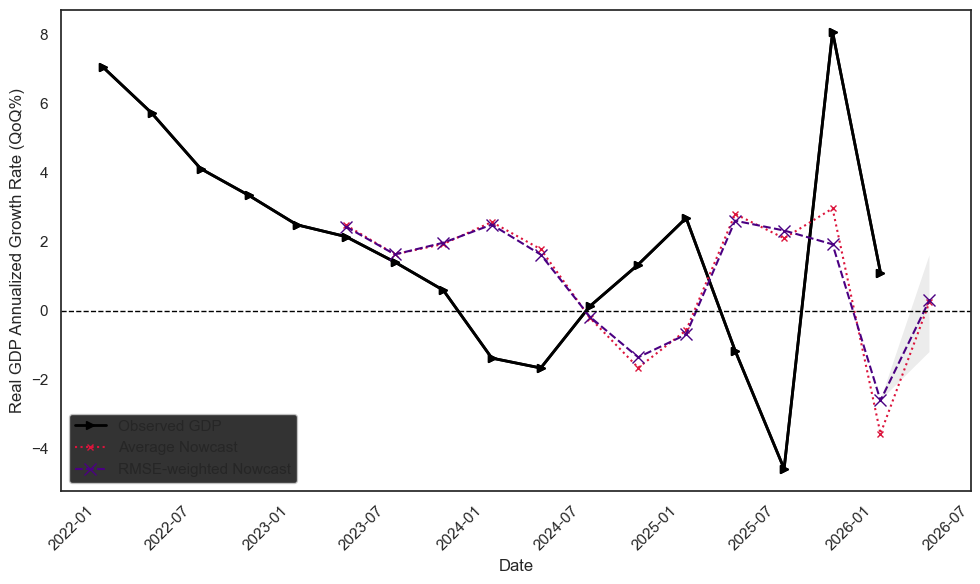

In [37]:
import matplotlib.pyplot as plt

dataframe = data.copy()

# Ensure the last observed point has no interval
last_valid_idx = dataframe['actuals'].last_valid_index()
dataframe.at[last_valid_idx, 'ci_lower'] = dataframe.at[last_valid_idx, 'weighted_avg']
dataframe.at[last_valid_idx, 'ci_upper'] = dataframe.at[last_valid_idx, 'weighted_avg']

# Restrict sample
dataframe = dataframe[dataframe.index > "2022-01-01"]

plt.figure(figsize=(10, 6))

# Confidence interval band
plt.fill_between(
    dataframe.index,
    dataframe['ci_lower'],
    dataframe['ci_upper'],
    color='grey',
    alpha=0.15,
    edgecolor='none',
    label="_nolegend_"
)

# Observed GDP
plt.plot(
    dataframe.index,
    dataframe['actuals'],
    color='black',
    marker='>',
    linewidth=2,
    label='Observed GDP'
)

# Average nowcast
plt.plot(
    dataframe.index,
    dataframe['avg'],
    color='crimson',
    linestyle=":",
    marker='x',
    markersize=5,
    label='Average Nowcast'
)

# Weighted nowcast
plt.plot(
    dataframe.index,
    dataframe['weighted_avg'],
    color='indigo',
    linestyle="--",
    marker='x',
    markersize=8,
    label='RMSE-weighted Nowcast'
)

# Zero line
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Labels
plt.xlabel('Date', fontsize=12)
plt.ylabel('Real GDP Annualized Growth Rate (QoQ%)', fontsize=12)

# Rotate x labels
plt.xticks(rotation=45)

# Remove duplicate legend entries (safety)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='lower left')

# Layout and save
plt.tight_layout()
plt.savefig(f"{PATH_OUTPUT}/{date_str} 4_rslt Fig out_of_sample.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

# β14 Operational dashboard charts

Three deliverables for the Bank of Jamaica MPC briefing, generated from the merged 3-seed pool:
1. **Headline fan** — actual GDP vs regime-aware consensus + 95% conformal interval
2. **Watchlist divergence** — consensus vs V+1 ENET/LASSO oracle + V+2 trees+PCA oracle
3. **Spec spread** — P25/P50/P75 of pooled forecasts per quarter (model disagreement)

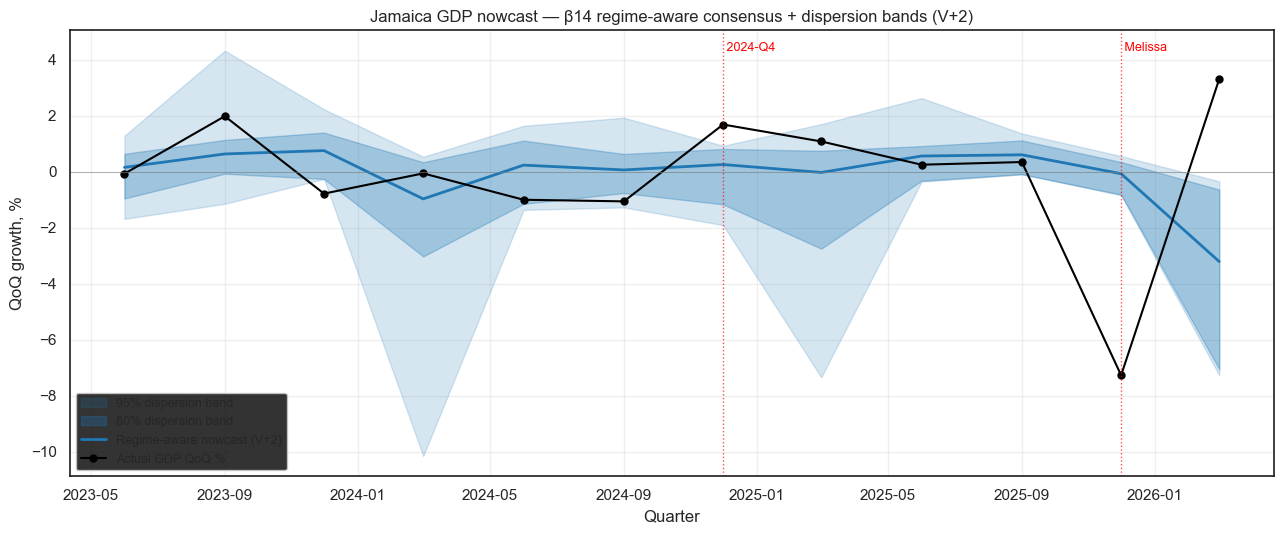

[OK] c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\Workshop DC\output\20260806/20260806 5_chart fan_headline_v2.png


In [46]:
# Headline fan chart: actual GDP + V+2 regime-aware consensus + 95% dispersion band
import matplotlib.pyplot as plt, pandas as pd, numpy as np

ra = pd.read_excel(f"{PATH_OUTPUT}/{date_str} 4_rslt regime_aware_nowcast.xlsx", parse_dates=["date"])
ci = pd.read_excel(f"{PATH_OUTPUT}/{date_str} 4_rslt dispersion_bands.xlsx", parse_dates=["date"])

# Use V+2 (most data, most accurate for past quarters; for the "next quarter" use the highest-vintage available)
V_HEADLINE = 2
ra_v = ra[ra["Vintage"]==V_HEADLINE].sort_values("date")
ci_v = ci[ci["Vintage"]==V_HEADLINE].sort_values("date")

fig, ax = plt.subplots(figsize=(13, 5.5))
# 95% dispersion band
ax.fill_between(ci_v["date"], ci_v["lo_95"], ci_v["hi_95"], alpha=0.18, color="tab:blue", label="95% dispersion band")
ax.fill_between(ci_v["date"], ci_v["lo_80"], ci_v["hi_80"], alpha=0.30, color="tab:blue", label="80% dispersion band")
# Consensus
ax.plot(ra_v["date"], ra_v["regime_aware_nowcast"], color="tab:blue", linewidth=2.0, label=f"Regime-aware nowcast (V+{V_HEADLINE})")
# Actuals
ax.plot(ra_v["date"], ra_v["actual"], color="black", linewidth=1.5, marker="o", markersize=5, label="Actual GDP QoQ %")

# Mark shocks
for d, lab in [("2024-12-01","2024-Q4"), ("2025-12-01","Melissa")]:
    dts = pd.Timestamp(d)
    if dts in set(ra_v["date"]):
        ax.axvline(dts, color="red", linestyle=":", linewidth=1, alpha=0.7)
        ax.text(dts, ax.get_ylim()[1]*0.92, " "+lab, color="red", fontsize=9, va="top")

ax.axhline(0, color="gray", linewidth=0.7, alpha=0.6)
ax.set_xlabel("Quarter")
ax.set_ylabel("QoQ growth, %")
ax.set_title(f"Jamaica GDP nowcast — β14 regime-aware consensus + dispersion bands (V+{V_HEADLINE})")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
out = f"{PATH_OUTPUT}/{date_str} 5_chart fan_headline_v{V_HEADLINE}.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] {out}")


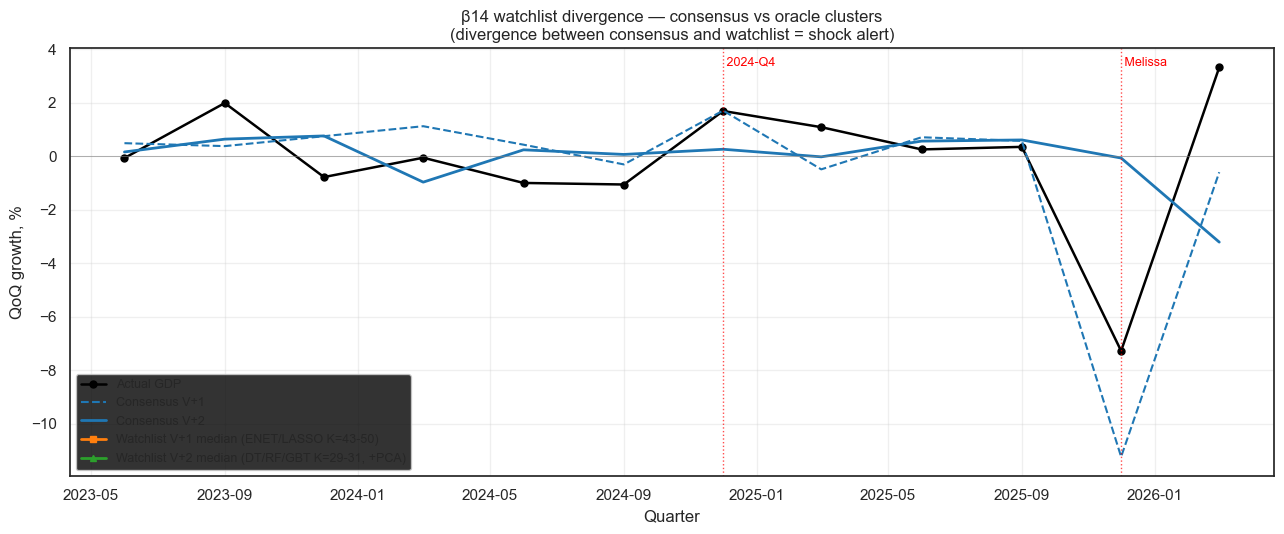

[OK] c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\Workshop DC\output\20260806/20260806 5_chart watchlist_divergence.png


In [47]:
# Watchlist divergence: consensus vs V+1 ENET/LASSO median vs V+2 trees+PCA median
import matplotlib.pyplot as plt, pandas as pd, numpy as np, re

fcst = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", parse_dates=["date"])
ra   = pd.read_excel(f"{PATH_OUTPUT}/{date_str} 4_rslt regime_aware_nowcast.xlsx", parse_dates=["date"])

VMAP = {"two_back":-2,"one_back":-1,"zero_back":0,"one_ahead":1,"two_ahead":2}
long = fcst.melt(id_vars=["date","spec","estimator","actuals"],  # no seed col: act8 fixes NWCST_SEED; only beta14a pools seeds
                 value_vars=list(VMAP), var_name="horizon", value_name="pred")
long["Vintage"] = long["horizon"].map(VMAP)

def _k_leading(s):
    m = re.match(r"^(?:lars|bench|flats)(\d+)", s)
    return int(m.group(1)) if m else None

# V+1 watchlist: ENET/LASSO at K in {43,47,48,49,50}, plain (no p3/p5/p5l2)
def _is_plain(s):
    return re.fullmatch(r"(?:lars|bench|flats)\d+", s) is not None
v1_watch = long[
    (long["Vintage"]==1) & (long["estimator"].isin(["ENET","LASSO"])) &
    (long["spec"].apply(lambda s: _k_leading(s) in {43,47,48,49,50} and _is_plain(s)))
]
v1_med = v1_watch.groupby("date")["pred"].median().rename("v1_watchlist_median")

# V+2 watchlist: DT/RF/GBT at K in {29,30,31}, with PCA variants p3/p5/p5l2
def _has_pca_variant(s):
    return bool(re.search(r"(p[0-9]+(l[0-9]+)?)$", s))
v2_watch = long[
    (long["Vintage"]==2) & (long["estimator"].isin(["DT","RF","GBT"])) &
    (long["spec"].apply(lambda s: _k_leading(s) in {29,30,31} and _has_pca_variant(s)))
]
v2_med = v2_watch.groupby("date")["pred"].median().rename("v2_watchlist_median")

# Consensus (regime-aware) at V+1 and V+2
consensus_v1 = ra[ra["Vintage"]==1].set_index("date")["regime_aware_nowcast"].rename("consensus_v1")
consensus_v2 = ra[ra["Vintage"]==2].set_index("date")["regime_aware_nowcast"].rename("consensus_v2")
actual = ra[ra["Vintage"]==2].set_index("date")["actual"].rename("actual")

dash_df = pd.concat([actual, consensus_v1, consensus_v2, v1_med, v2_med], axis=1).sort_index()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(dash_df.index, dash_df["actual"],        color="black",     linewidth=1.8, marker="o", markersize=5, label="Actual GDP")
ax.plot(dash_df.index, dash_df["consensus_v1"],  color="tab:blue",  linewidth=1.5, linestyle="--", label="Consensus V+1")
ax.plot(dash_df.index, dash_df["consensus_v2"],  color="tab:blue",  linewidth=2.0, label="Consensus V+2")
ax.plot(dash_df.index, dash_df["v1_watchlist_median"], color="tab:orange", linewidth=2.0, marker="s", markersize=4, label="Watchlist V+1 median (ENET/LASSO K=43-50)")
ax.plot(dash_df.index, dash_df["v2_watchlist_median"], color="tab:green",  linewidth=2.0, marker="^", markersize=4, label="Watchlist V+2 median (DT/RF/GBT K=29-31, +PCA)")

for d, lab in [("2024-12-01","2024-Q4"), ("2025-12-01","Melissa")]:
    dts = pd.Timestamp(d)
    if dts in dash_df.index:
        ax.axvline(dts, color="red", linestyle=":", linewidth=1, alpha=0.7)
        ax.text(dts, ax.get_ylim()[1]*0.92, " "+lab, color="red", fontsize=9, va="top")

ax.axhline(0, color="gray", linewidth=0.7, alpha=0.6)
ax.set_xlabel("Quarter"); ax.set_ylabel("QoQ growth, %")
ax.set_title("β14 watchlist divergence — consensus vs oracle clusters\n(divergence between consensus and watchlist = shock alert)")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
out = f"{PATH_OUTPUT}/{date_str} 5_chart watchlist_divergence.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] {out}")


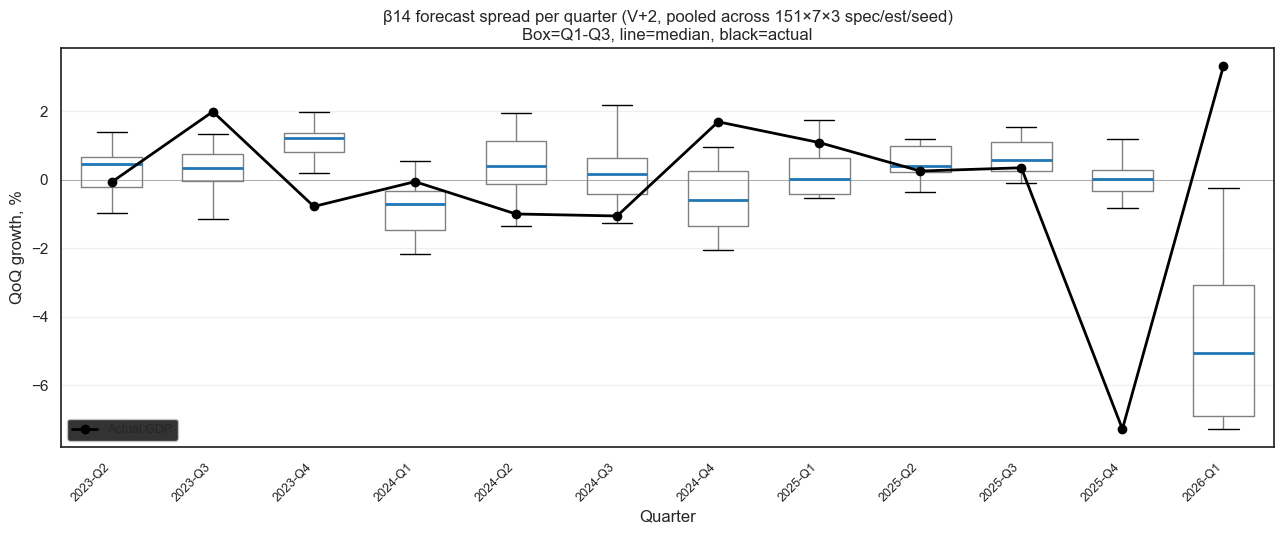

[OK] c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\Workshop DC\output\20260806/20260806 5_chart spec_spread_v2.png


In [48]:
# Spec-spread boxplot per quarter at V+2 (the headline vintage)
import matplotlib.pyplot as plt, pandas as pd, numpy as np

fcst = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", parse_dates=["date"])
VMAP = {"two_back":-2,"one_back":-1,"zero_back":0,"one_ahead":1,"two_ahead":2}
long = fcst.melt(id_vars=["date","spec","estimator","actuals"],  # no seed col: act8 fixes NWCST_SEED; only beta14a pools seeds
                 value_vars=list(VMAP), var_name="horizon", value_name="pred")
long["Vintage"] = long["horizon"].map(VMAP)

V_HEADLINE = 2
sub = long[long["Vintage"]==V_HEADLINE].copy()
sub_actual = sub.groupby("date")["actuals"].first()
groups = [g["pred"].dropna().values for _, g in sub.groupby("date")]
labels = [f"{pd.Timestamp(d).year}-Q{((pd.Timestamp(d).month-1)//3)+1}"
          for d in sub.groupby("date").groups.keys()]

fig, ax = plt.subplots(figsize=(13, 5.5))
positions = list(range(len(groups)))
bp = ax.boxplot(groups, positions=positions, widths=0.6, showfliers=False,
                medianprops=dict(color="tab:blue", linewidth=2),
                boxprops=dict(color="gray"), whiskerprops=dict(color="gray"))
ax.plot(positions, sub_actual.values, color="black", linewidth=2.0, marker="o", markersize=6, label="Actual GDP", zorder=5)
ax.axhline(0, color="gray", linewidth=0.7, alpha=0.6)
ax.set_xticks(positions); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Quarter"); ax.set_ylabel("QoQ growth, %")
ax.set_title(f"β14 forecast spread per quarter (V+{V_HEADLINE}, pooled across 151×7×3 spec/est/seed)\nBox=Q1-Q3, line=median, black=actual")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
out = f"{PATH_OUTPUT}/{date_str} 5_chart spec_spread_v{V_HEADLINE}.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] {out}")
